# EDA Notebook

## 1. Importar librerías necesarias
Importar pandas, numpy, matplotlib y seaborn para el análisis y visualización de datos.

In [2]:
import sys
from pathlib import Path

# Añadir carpeta raíz del proyecto al path
ROOT = Path().resolve().parent

sys.path.append(str(ROOT))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import TRAIN_PATH, TEST_PATH
from src.io import load_data
from src.cleaning import clean_data
from src.features import build_features

sns.set(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

## OBJETIVO

Queremos analizar la satisfacción de los pasajeros de aerolíneas
e identificar los factores que influyen en la experiencia
del cliente.

Preguntas principales:
- ¿Influye la clase del vuelo en la satisfacción?
- ¿Afectan los retrasos a la experiencia del pasajero?
- ¿Qué servicios reciben mejores valoraciones?
- ¿Los clientes leales están más satisfechos?

## 2. Cargar el archivo CSV
Solicitar al usuario la ruta del archivo .csv y cargarlo en un DataFrame de pandas.

In [4]:
# Change this path to point to your data file
# Cargar dataset unificado (train + test)
df = load_data(TRAIN_PATH, TEST_PATH)

# Mostrar dimensiones del dataset
print(df.shape)


(129880, 24)


## 3. Visualizar las primeras filas del dataset
Mostrar las primeras filas del DataFrame usando head() para obtener una vista general de los datos.

In [5]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 4. Explorar información general del dataset
Utilizar info() y shape para mostrar información sobre el número de filas, columnas y tipos de datos.

In [6]:
df.info()
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

<class 'pandas.DataFrame'>
Index: 129880 entries, 0 to 25975
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 129880 non-null  int64  
 1   Gender                             129880 non-null  str    
 2   Customer Type                      129880 non-null  str    
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  str    
 5   Class                              129880 non-null  str    
 6   Flight Distance                    129880 non-null  int64  
 7   Inflight wifi service              129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Ease of Online booking             129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Food and drink                     129880 non-null  int6

## 5. Describir variables numéricas y categóricas
Usar describe() para variables numéricas y value_counts() para variables categóricas.

In [ ]:
# Numerical variables
df.describe(include="all")

# Categorical values (Example for a columnn)
# df['category_column'].value_counts()

id      Gender  Customer Type      Age  Type of Travel   Class     Flight Distance  Inflight wifi service  Departure/Arrival time convenient  Ease of Online booking  Gate location  Food and drink  Online boarding  Seat comfort  Inflight entertainment  On-board service  Leg room service  Baggage handling  Checkin service  Inflight service  Cleanliness  Departure Delay in Minutes  Arrival Delay in Minutes  satisfaction           
70172   Male    Loyal Customer     13   Personal Travel  Eco Plus  460              3                      4                                  3                       1              5               3                5             5                       4                 3                 4                 4                5                 5            25                          18.0                      neutral or dissatisfied    1
5047    Male    disloyal Customer  25   Business travel  Business  235              3                      2                       

## 6. Visualizar valores nulos y duplicados
Identificar y visualizar la cantidad de valores nulos y filas duplicadas en el dataset.

In [11]:
# Null values
print(df.isnull().sum())

# Duplicated rows
print(df.duplicated().sum())

id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64
0


# Limpieza de datos

In [ ]:
# Aplicar limpieza de datos
df = clean_data(df)

# Visualizar resultado
df.head()

,id,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,...,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [14]:
# Crear nuevas variables/features
df = build_features(df)

# Visualizar resultado
df.head()

,id,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,...,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction,total_delay,is_premium_customer,age_group
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,4,4,5,5,25,18.0,neutral or dissatisfied,43.0,1,Teen
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,3,1,4,1,1,6.0,neutral or dissatisfied,7.0,0,Young Adult
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,4,4,4,5,0,0.0,satisfied,0.0,1,Young Adult
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,3,1,4,2,11,9.0,neutral or dissatisfied,20.0,1,Young Adult
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,4,3,3,3,0,0.0,satisfied,0.0,1,Senior


In [15]:
# Mostrar nombres de columnas
df.columns

Index(['id', 'gender', 'customer_type', 'age', 'type_of_travel', 'class',
       'flight_distance', 'inflight_wifi_service',
       'departure/arrival_time_convenient', 'ease_of_online_booking',
       'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
       'inflight_entertainment', 'on-board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'inflight_service',
       'cleanliness', 'departure_delay_in_minutes', 'arrival_delay_in_minutes',
       'satisfaction', 'total_delay', 'is_premium_customer', 'age_group'],
      dtype='str')

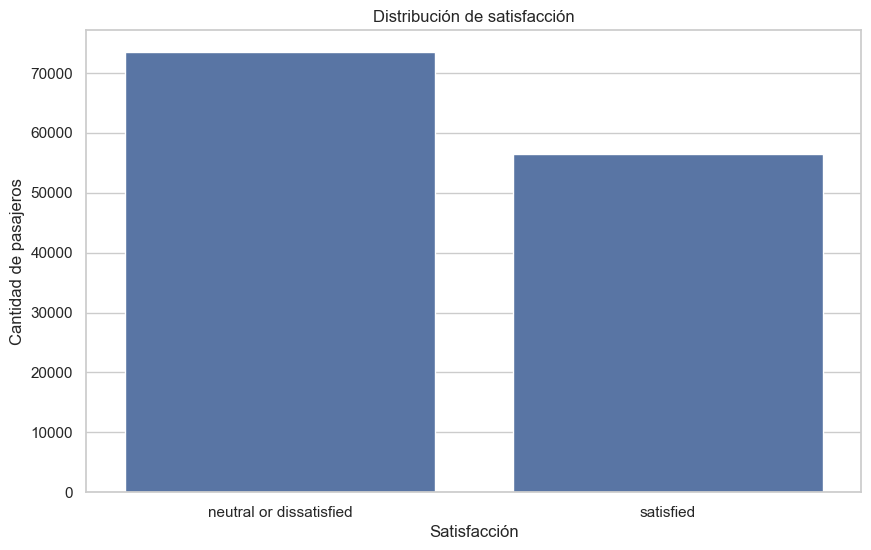

## 7. Análisis univariado de variables numéricas
Realizar histogramas y boxplots para analizar la distribución de las variables numéricas.

In [ ]:
# Histogram for a numerical variable
# df['numeric_column'].hist()
# plt.show()

# Boxplot
# df.boxplot(column='numeric_column')
# plt.show()

## 8. Análisis univariado de variables categóricas
Realizar gráficos de barras para analizar la frecuencia de las variables categóricas.

In [ ]:
# Bar plot for a categorical variable
# Distribución de satisfacción de pasajeros
sns.countplot(
    data=df,
    x="satisfaction"
)

plt.title("Distribución de satisfacción")

plt.xlabel("Satisfacción")

plt.ylabel("Cantidad de pasajeros")

plt.show()

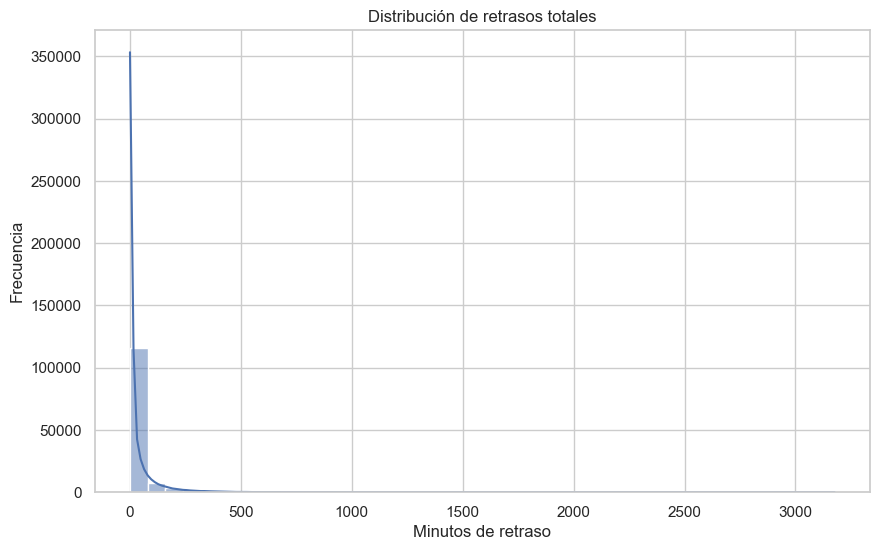

In [18]:
# Distribución del retraso total
sns.histplot(
    df["total_delay"],
    bins=40,
    kde=True
)

plt.title("Distribución de retrasos totales")

plt.xlabel("Minutos de retraso")

plt.ylabel("Frecuencia")

plt.show()

## 9. Análisis bivariado entre variables
Explorar relaciones entre variables numéricas y categóricas mediante scatterplots y tablas cruzadas.

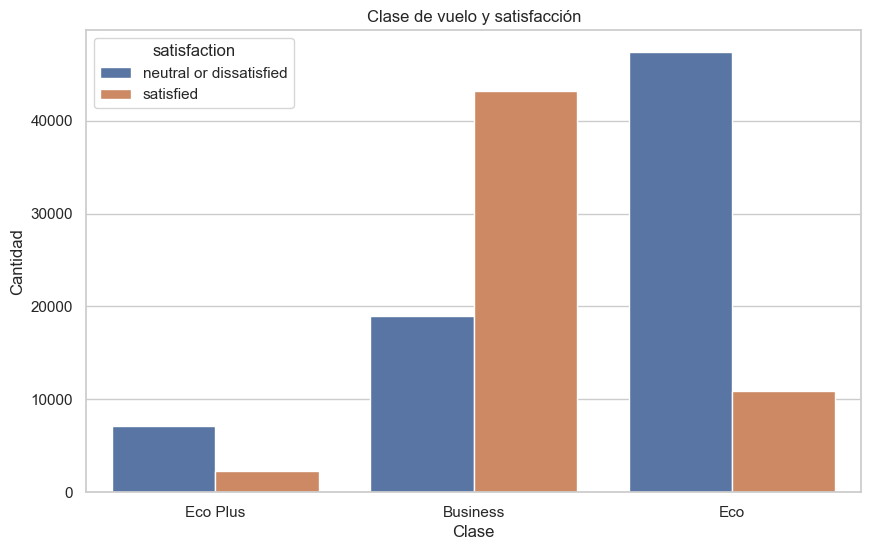

In [17]:
# Relación entre clase de vuelo y satisfacción
sns.countplot(
    data=df,
    x="class",
    hue="satisfaction"
)

plt.title("Clase de vuelo y satisfacción")

plt.xlabel("Clase")

plt.ylabel("Cantidad")

plt.show()

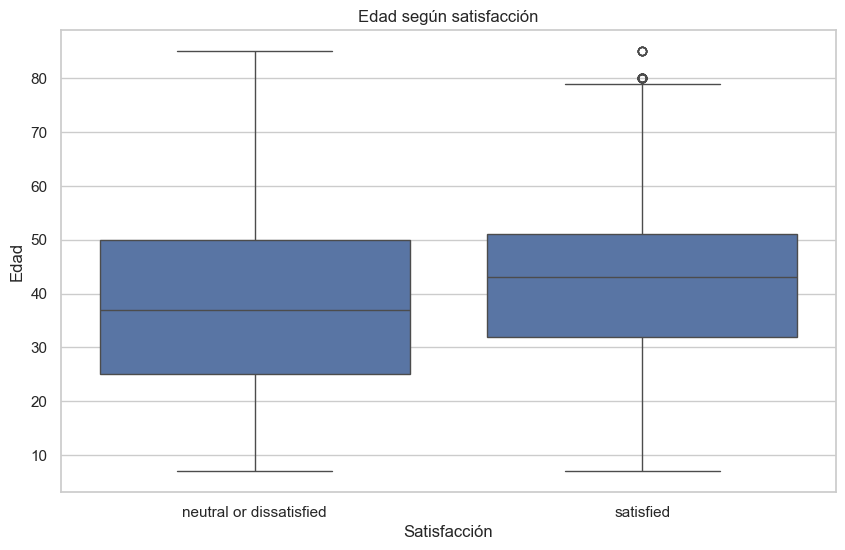

In [19]:
# Relación entre edad y satisfacción
sns.boxplot(
    data=df,
    x="satisfaction",
    y="age"
)

plt.title("Edad según satisfacción")

plt.xlabel("Satisfacción")

plt.ylabel("Edad")

plt.show()

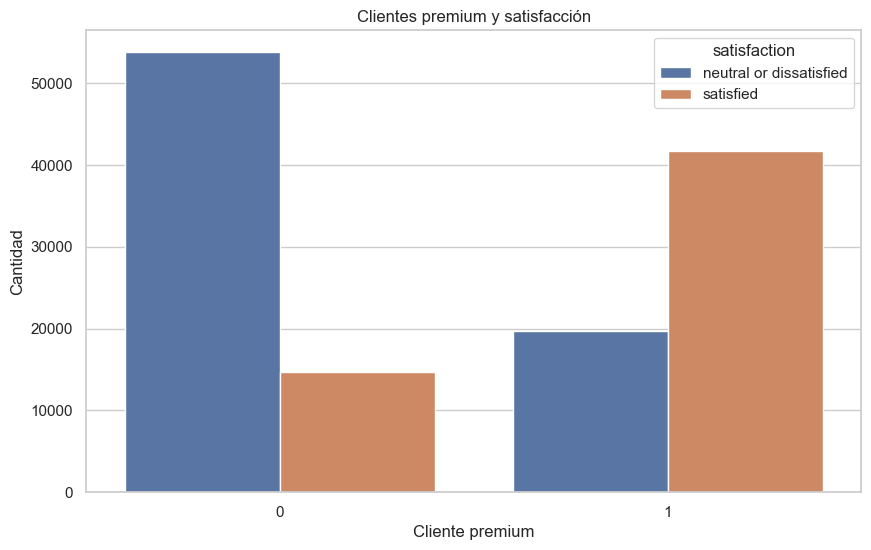

In [20]:
# Relación entre clientes premium y satisfacción
sns.countplot(
    data=df,
    x="is_premium_customer",
    hue="satisfaction"
)

plt.title("Clientes premium y satisfacción")

plt.xlabel("Cliente premium")

plt.ylabel("Cantidad")

plt.show()

## 10. Visualización de correlaciones
Calcular y visualizar la matriz de correlación entre variables numéricas usando un heatmap.

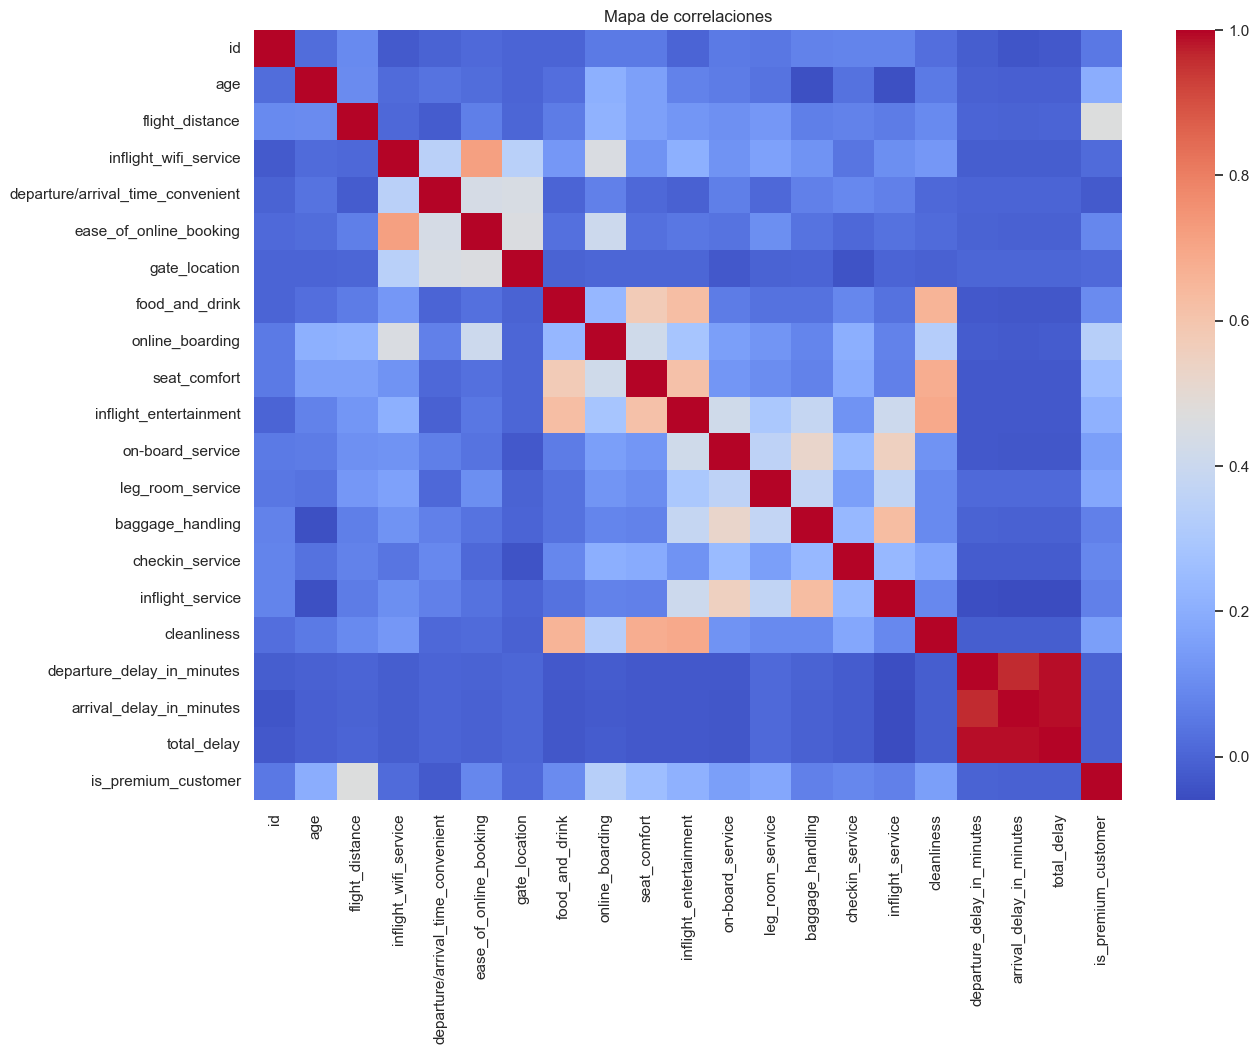

In [21]:
# Correlation matrix
# Seleccionar variables numéricas
numeric_df = df.select_dtypes(include=np.number)

# Calcular correlaciones
corr = numeric_df.corr()

# Crear heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Mapa de correlaciones")

plt.show()

Valoración de servicios

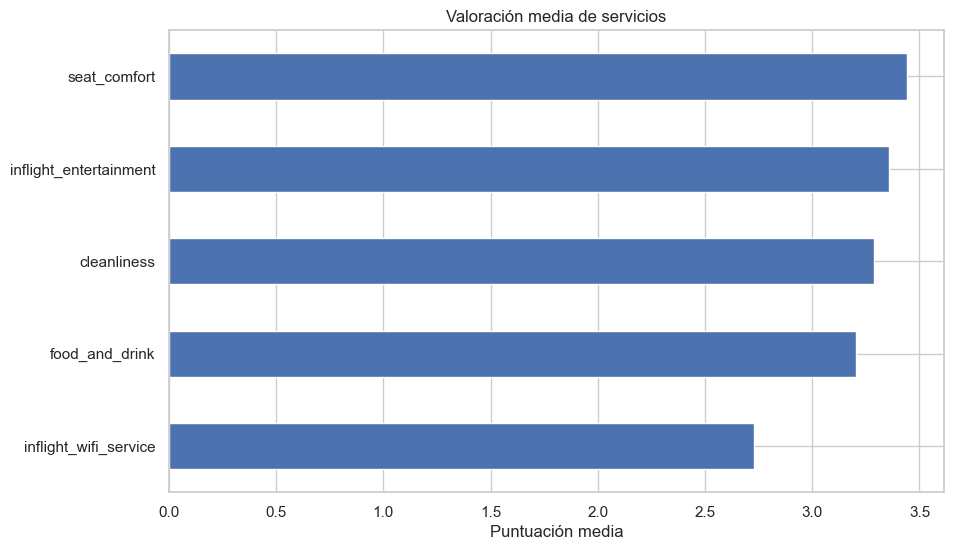

In [22]:
# Variables de servicios
service_cols = [
    "inflight_wifi_service",
    "food_and_drink",
    "seat_comfort",
    "inflight_entertainment",
    "cleanliness"
]

# Media de puntuaciones
service_means = (
    df[service_cols]
    .mean()
    .sort_values()
)

# Gráfico
service_means.plot(kind="barh")

plt.title("Valoración media de servicios")

plt.xlabel("Puntuación media")

plt.show()

Distancia media por grupo de edad

In [23]:
# Distancia media de vuelo por grupo de edad
df.groupby("age_group")["flight_distance"].mean()

age_group
Teen            927.605781
Young Adult    1038.742603
Adult          1253.894798
Mature         1379.588058
Senior          961.391387
Name: flight_distance, dtype: float64

Satisfacción por clase

In [25]:
(df.groupby("class")["satisfaction"].value_counts(normalize=True)*100)

class     satisfaction           
Business  satisfied                  69.443372
          neutral or dissatisfied    30.556628
Eco       neutral or dissatisfied    81.232743
          satisfied                  18.767257
Eco Plus  neutral or dissatisfied    75.358623
          satisfied                  24.641377
Name: proportion, dtype: float64

## Conclusiones
1. Los pasajeros de clase Business presentan mayores
niveles de satisfacción.

2. Los retrasos elevados están relacionados con
experiencias negativas.

3. Los clientes leales muestran una mayor satisfacción.

4. Los servicios mejor valorados son:
   - Comodidad del asiento
   - Entretenimiento a bordo
   - Limpieza

5. Los pasajeros de clase Economy presentan menores
niveles de satisfacción general.

Exportamos el dataset limpio

In [26]:
# Exportar dataset procesado
df.to_csv(
    "../data/processed/clean_airline_passenger_satisfaction.csv",
    index=False
)

print("Dataset exportado correctamente")

Dataset exportado correctamente


## Resumen del pipeline
PIPELINE DEL PROYECTO

1. Carga de datasets train y test
2. Unión de datasets
3. Limpieza de datos
4. Tratamiento de valores nulos
5. Creación de nuevas variables
6. Análisis exploratorio (EDA)
7. Generación de visualizaciones
8. Exportación del dataset limpio